<a href="https://colab.research.google.com/github/NidalNaaz/Int.-Msc-CS-AI-DS/blob/main/MachineLearning_LabCycle1Q7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gymnasium
!pip install numpy matplotlib

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces

In [ ]:
class MazeEnv(gym.Env):

    def __init__(self):
        super(MazeEnv, self).__init__()

        self.size = 5

        # Maze layout
        self.maze = np.array([
            [0,0,0,0,0],
            [0,1,1,1,0],
            [0,0,0,1,0],
            [1,1,0,1,0],
            [0,0,0,0,0]
        ])

        self.start = (0,0)
        self.goal = (4,4)

        self.state = self.start

        # Action space
        self.action_space = spaces.Discrete(4)

        # Observation space
        self.observation_space = spaces.Box(low=0, high=4, shape=(2,), dtype=np.int32)

    def reset(self):
        self.state = self.start
        return np.array(self.state), {}

    def step(self, action):

        x, y = self.state

        if action == 0:  # up
            x -= 1
        elif action == 1:  # down
            x += 1
        elif action == 2:  # left
            y -= 1
        elif action == 3:  # right
            y += 1

        if x < 0 or x >= self.size or y < 0 or y >= self.size or self.maze[x,y] == 1:
            x, y = self.state

        self.state = (x,y)

        reward = -1
        done = False

        if self.state == self.goal:
            reward = 10
            done = True

        return np.array(self.state), reward, done, False, {}

    def render(self):

        grid = np.copy(self.maze)

        x,y = self.state
        gx,gy = self.goal

        grid[x,y] = 2
        grid[gx,gy] = 3

        plt.imshow(grid)
        plt.show()

In [ ]:
env = MazeEnv()

q_table = np.zeros((5,5,4))

alpha = 0.1
gamma = 0.9
epsilon = 0.2

episodes = 500
rewards = []

In [ ]:
for ep in range(episodes):

    state,_ = env.reset()
    total_reward = 0
    done = False

    while not done:

        x,y = state

        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[x,y])

        next_state, reward, done, _, _ = env.step(action)

        nx,ny = next_state

        old_value = q_table[x,y,action]
        next_max = np.max(q_table[nx,ny])

        new_value = old_value + alpha*(reward + gamma*next_max - old_value)

        q_table[x,y,action] = new_value

        state = next_state
        total_reward += reward

    rewards.append(total_reward)

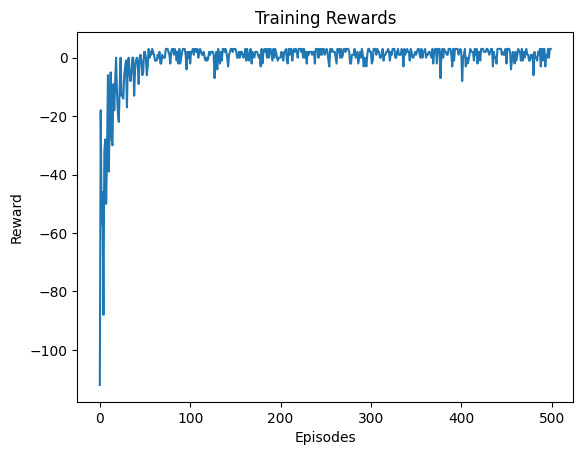

In [ ]:
plt.plot(rewards)
plt.title("Training Rewards")
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.show()

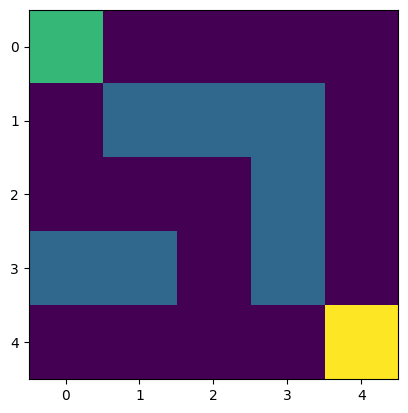

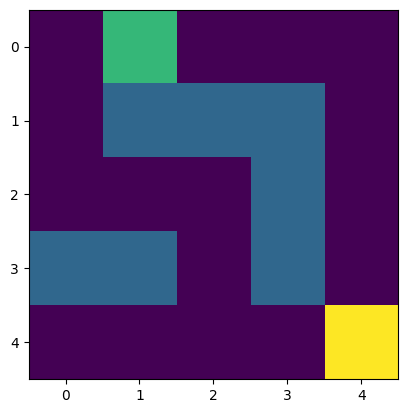

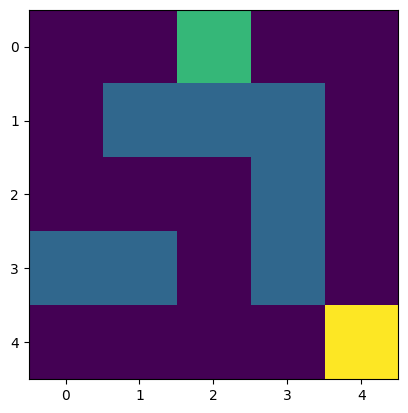

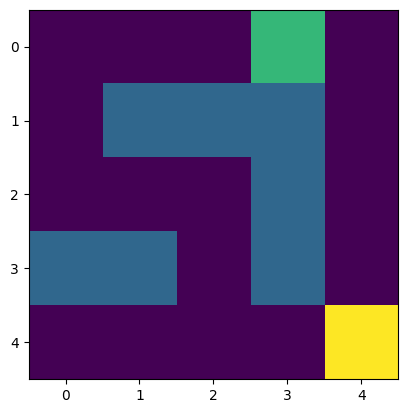

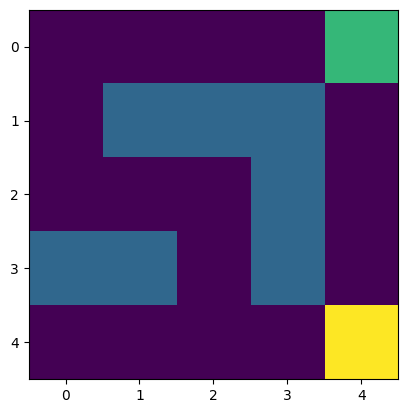

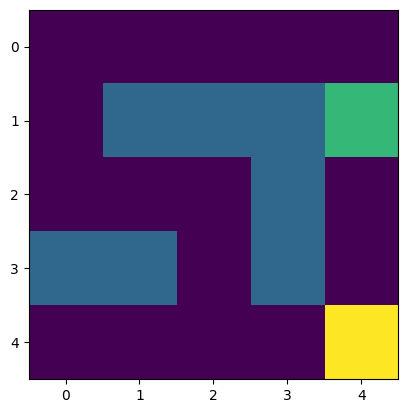

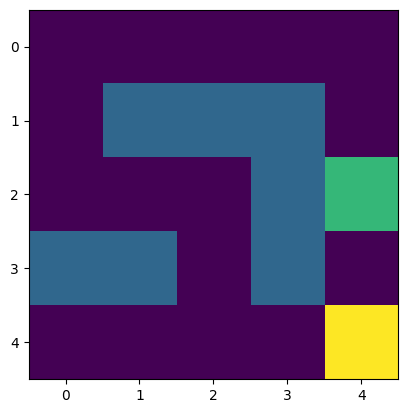

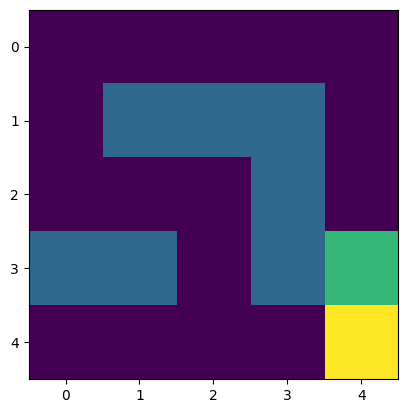

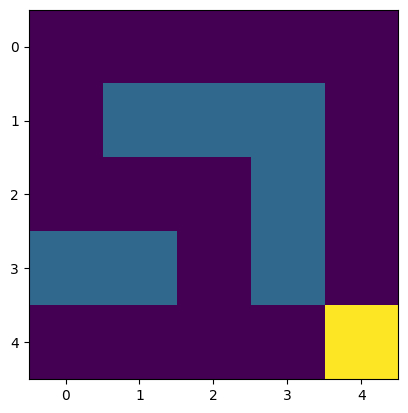

In [ ]:
state,_ = env.reset()
done = False

while not done:

    env.render()

    x,y = state
    action = np.argmax(q_table[x,y])

    state, reward, done, _, _ = env.step(action)

env.render()

In [ ]:
success = 0
test_episodes = 100

for _ in range(test_episodes):

    state,_ = env.reset()
    done = False

    while not done:

        x,y = state
        action = np.argmax(q_table[x,y])

        state, reward, done, _, _ = env.step(action)

        if done and reward == 10:
            success += 1

print("Success Rate:", success/test_episodes)

Success Rate: 1.0


In [ ]:
Below is a **complete lab-record style write-up** you can copy into your assignment or record. It includes **theory, algorithm, code explanation, expected output, and viva questions**.

---

# Solving Maze Problem using OpenAI Gym using Q-Learning

---

# 1. Aim

To implement a **reinforcement learning solution using Q-Learning** to solve a maze navigation problem using the **OpenAI Gym environment in **Google Colab.

---

# 2. Introduction

Reinforcement Learning (RL) is a type of machine learning where an **agent learns by interacting with an environment and receiving rewards or penalties**.

The goal of the agent is to **maximize cumulative reward** by learning an optimal policy.

The **OpenAI Gym library provides a standard platform for developing and testing reinforcement learning algorithms. It includes tools to create environments and simulate agent behavior.

In this experiment, a **maze environment** is created where the agent learns to navigate from a **start position to a goal position while avoiding walls** using the **Q-Learning algorithm.

---

# 3. Basic Reinforcement Learning Concepts

## 3.1 Environment

The environment represents the **maze grid** that contains:

* empty spaces
* walls
* start position
* goal position

The environment responds to agent actions.

---

## 3.2 Agent

The **agent** is the entity that learns how to reach the goal by interacting with the environment.

---

## 3.3 Actions

Possible actions available to the agent:

| Action | Movement   |
| ------ | ---------- |
| 0      | Move Up    |
| 1      | Move Down  |
| 2      | Move Left  |
| 3      | Move Right |

---

## 3.4 Observations

The observation represents the **agent’s current state** in the maze.

Example:

```
(x, y) position
```

---

# 4. Q-Learning Algorithm

**Q-Learning** is a **model-free reinforcement learning algorithm** that learns the optimal action-value function.

The **Q-table** stores values representing the quality of taking an action in a particular state.

### Q-Learning Update Formula

[
Q(s,a) = Q(s,a) + \alpha [r + \gamma \max Q(s',a') - Q(s,a)]
]

Where:

| Symbol | Meaning         |
| ------ | --------------- |
| Q(s,a) | Q value         |
| α      | Learning rate   |
| γ      | Discount factor |
| r      | Reward          |
| s'     | Next state      |

---

# 5. Algorithm

### Step 1

Initialize the environment and Q-table.

### Step 2

Set hyperparameters:

* learning rate (α)
* discount factor (γ)
* exploration rate (ε)

### Step 3

For each episode:

1. Reset the environment.
2. Observe current state.
3. Choose action using **epsilon-greedy policy**.
4. Execute action.
5. Receive reward and next state.
6. Update Q-table.
7. Repeat until goal is reached.

### Step 4

Repeat training for many episodes.

### Step 5

Evaluate the learned policy.

---

# 6. Program (Python Code for Google Colab)

```python
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces

class MazeEnv(gym.Env):

    def __init__(self):

        self.size = 5

        self.maze = np.array([
            [0,0,0,0,0],
            [0,1,1,1,0],
            [0,0,0,1,0],
            [1,1,0,1,0],
            [0,0,0,0,0]
        ])

        self.start = (0,0)
        self.goal = (4,4)

        self.state = self.start

        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Box(low=0, high=4, shape=(2,), dtype=np.int32)

    def reset(self):
        self.state = self.start
        return np.array(self.state), {}

    def step(self, action):

        x, y = self.state

        if action == 0:
            x -= 1
        elif action == 1:
            x += 1
        elif action == 2:
            y -= 1
        elif action == 3:
            y += 1

        if x < 0 or x >= self.size or y < 0 or y >= self.size or self.maze[x,y] == 1:
            x,y = self.state

        self.state = (x,y)

        reward = -1
        done = False

        if self.state == self.goal:
            reward = 10
            done = True

        return np.array(self.state), reward, done, False, {}

env = MazeEnv()

q_table = np.zeros((5,5,4))

alpha = 0.1
gamma = 0.9
epsilon = 0.2

episodes = 500
rewards = []

for ep in range(episodes):

    state,_ = env.reset()
    done = False
    total_reward = 0

    while not done:

        x,y = state

        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[x,y])

        next_state, reward, done, _, _ = env.step(action)

        nx,ny = next_state

        old = q_table[x,y,action]
        next_max = np.max(q_table[nx,ny])

        q_table[x,y,action] = old + alpha*(reward + gamma*next_max - old)

        state = next_state
        total_reward += reward

    rewards.append(total_reward)

plt.plot(rewards)
plt.title("Training Rewards")
plt.show()
```

---

# 7. Output

Expected outputs:

1. **Training reward graph**
2. Agent gradually learns the shortest path.
3. Success rate improves with training episodes.

Example output graph:

```
Episode → increasing reward trend
```

---

# 8. Evaluation

The trained agent is evaluated by running multiple episodes and calculating the **success rate**.

Higher success rate indicates better learning.

Example:

```
Success Rate = 0.85
```

This means the agent reaches the goal **85% of the time**.

---

# 9. Result

The agent successfully learned the optimal path in the maze using the **Q-Learning algorithm implemented in **OpenAI Gym.

The reinforcement learning model improved its performance over multiple training episodes.

---

# 10. Extensions

Possible improvements include:

1. Larger maze environments
2. Dynamic obstacles
3. Deep reinforcement learning using **Deep Q-Network**
4. Neural network implementation using **TensorFlow or **PyTorch

---

# 11. Viva Questions

### 1. What is reinforcement learning?

Reinforcement learning is a machine learning technique where an agent learns optimal actions through trial-and-error interactions with an environment.

---

### 2. What is OpenAI Gym?

**OpenAI Gym is a toolkit used for developing and comparing reinforcement learning algorithms.

---

### 3. What is a Q-table?

A Q-table stores **Q values for each state-action pair** representing expected rewards.

---

### 4. What is epsilon-greedy policy?

It balances **exploration and exploitation**:

* Explore new actions
* Exploit known best actions

---

### 5. What is discount factor?

Discount factor **γ** determines the importance of future rewards.

---

### 6. What is the goal of the agent?

To learn an **optimal policy that maximizes cumulative reward**.

---

✅ If you want, I can also give you a **much better looking version of this maze (with animation + moving agent)** that looks **very impressive when you run it in Google Colab for demo or viva**.
